#**Decision Tree Classifier with the Palmer Penguins Data Set**
## Machine Learning with Python
## Nathan Ferry
## Atlantic Technological University, Galway

<br><br>

#Introduction

* The Palmer Penguins data set contains data collected from Antarctica from three different species of penguins [1]. In this notebook a machine learning decision tree model was created and analysed for the penguins data set. The stages of how this was done and the techniques used to analyse the dataset itself are explained later in the notebook.

* Over the course of this Notebook, the palmer penguins data set was loaded in, analysed using an array of charts, graphs, other techniques and finally, a decision tree was created.

* A decision tree is a supervised learning algorithm used in machine learning [2]. In the e-book *Machine Learning for Humans*, the author compares a decision tree to a game of 20 questions [3].

* In my course, we previously applied the decision tree approach to the well-known Iris data set [4]. This laid the groundwork for this project that was expanded upon with techniques such as cross-validation, trend lines in particular graphs, a color scheme that remained unchanged from chart to chart and other techniques for better analysis and data visualisation.

##What is the palmer penguin dataset?
* The palmer penguins dataset [1] was created to study "foraging behaviour and its relationship with environmental variability" [5] of penguins in the Antarctic. This involved studying three species all of whom inhabited different islands.

##Why use this dataset?
This dataset was a good candidate for analysis due to being large enough for analysis, having variance (i.e. 3 species) and an array of features to analyze. This lead to options for analysing the dataset as a whole, by species, by feature or a mixture.



#Loading the Penguins Data Set

* To begin, the data was first imported from google drive [6]. The drive was mounted in order to use the dataset downloaded there.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* Using Linux commands, the working directory was printed to ensure that the working directory was the right location in drive. The list command was used to check for the .csv file with the penguins dataset. The penguins.csv file was listed, thus cementing the fact that the drive was mounted correctly.

In [ ]:
!pwd
!ls drive/MyDrive/

/content
'Colab Notebooks'   KMeansDigits_Lab.ipynb	       penguins.csv
 DTIris_Lab.ipynb   NotebookWithReferencesIEEE.ipynb


#Initial Thoughts

* The libraries pandas and sklearn were imported before the dataset was read and stored in "penguins". The dataset was then printed to check all was operational. It showed a selection of data in the head and tail of the dataset.

* Information is already readily available from the glimpse that printed to the terminal. For example, there were at least two species (there are in fact three), there were some missing values for features that appear as "NaN" or not a number, two islands could also be seen (again there are three but due to only seeing a sample we cannot know this yet),the row and column numbers show the dataset size, and finally, features of the dataset such as "species", "bill_length", "bill_length", "bill_depth", "flipper_length","body_mass" and "sex" could be seen. These features described the animals themselves but there were also features that described the habitat or "island" and the date the data was recorded or "year".

In [ ]:
import pandas as pd
import sklearn

penguins = pd.read_csv("drive/MyDrive/penguins.csv")

print(penguins)

       species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0       Adelie  Torgersen            39.1           18.7              181.0   
1       Adelie  Torgersen            39.5           17.4              186.0   
2       Adelie  Torgersen            40.3           18.0              195.0   
3       Adelie  Torgersen             NaN            NaN                NaN   
4       Adelie  Torgersen            36.7           19.3              193.0   
..         ...        ...             ...            ...                ...   
339  Chinstrap      Dream            55.8           19.8              207.0   
340  Chinstrap      Dream            43.5           18.1              202.0   
341  Chinstrap      Dream            49.6           18.2              193.0   
342  Chinstrap      Dream            50.8           19.0              210.0   
343  Chinstrap      Dream            50.2           18.7              198.0   

     body_mass_g     sex  year  
0         3750.0  

# Penguins Data Set Analysis

##Removing Gaps in the Data

* Earlier when the data was printed some values were missing. To remove missing values first "penguins" was converted to a pandas dataframe named "df_penguins". This new dataframe was printed using the describe()[7] method to print print the data showing the quartiles, standard deviation, mean and other measurable statistical values. Once the data  was cleaned, it is clearer to see the measurable change in these numbers rather than simply the absence of NaN (not a number) variables if the dataset was printed as previously. The terminal below displayed the count of the data or number of samples.

* The average or mean of the data can be used to compare species, outliers in feature values or simply average values across features. The standard deviation (std) can be used to see how accurate the mean is. This is because if the std is large relative to the mean (i.e.an std of 10 and mean of 40) the mean isn't accurate as the data is spread out among the data range. For example, the mean for body_mass_g is 4201.754386 and for this feature std/mean = 801.954536/4201.754386 meant the std was 19.09% of the mean. The std for "flipper_length_mm" was 14.061714 which meant that the std was 14.061714/200.915205 or roughly 6.99% of the mean. Both of these standard deviations indicate a large spread but for the flipper length, the data would be less spread out.

* There could have been a number of factors to account for the stds being this large relative to features across all features (excluding years as they would naturally have had only three values leading to a smaller std) for example, the set was not just measuring one species but three. If there was a small, medium and large species and presuming a larger species would have bigger features or a smaller species smaller features etc, this could account for the large relative stds seen. There were also multiple islands that the penguins inhabited, and separate islands could have had differing environments and resources such as food. Therefore, if one island had a plentiful supply of food, the penguins could have been larger and if there was no food on another island the penguins could have been smaller to which would account for the stds.

* The quartiles measure a feature from the smallest value in the range to the largest. There are four quartiles and these measure differing subranges i.e. from the smallest values in the data, at 25% of the max range, 50%, 75% and the maximum value. This information paints a more complete picture along with std and mean of the entire range of each feature.  

In [ ]:
df_penguins=pd.DataFrame(penguins)
print("Data before cleaning:\n")
print(df_penguins.describe())

Data before cleaning:

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   344.000000  
mean   2008.029070  
std       0.818356  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  


* The "penguins" dataset was cleaned before being converted to a second pandas dataframe. The number of missing data points was counted by summing (using .sum()) the amount of null (using .isnull()) [8] data points in "penguins". The number of these missing points were printed to the screen.
*  "pen" was used to store the dataset with removed data points as it was set to the original dataset and using the .dropna() method, all missing points were removed to clean the data.

* "pen" was used to create the "df_pen" pandas dataframe. The data was printed once again using the describe method. You can now directly compare the two sets. Firstly, the sum of missing data points were all zero's once cleaning took place. The total count for the data dropped from 342 to 333 which resulted in a 2.63% loss in data.

* This change in the sample number had changed the values of the statistical variables found with the .describe() function. There was a change in the mean, std and quartiles. The minimum and max values for features were left unchanged.

* In a personal communication with my colleague Alex Paton, implementation of data removal was discussed [9] {"data removal"}.

In [ ]:
print("Sum of missing data before removal:\n", penguins.isnull().sum())
pen = penguins.dropna()
print("Sum of missing data after removal:\n", pen.isnull().sum())
df_pen=pd.DataFrame(pen)
print("\n\nData after cleaning:\n")
print(df_pen.describe())

Sum of missing data before removal:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
Sum of missing data after removal:
 species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64


Data after cleaning:

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      333.000000     333.000000         333.000000   333.000000   
mean        43.992793      17.164865         200.966967  4207.057057   
std          5.468668       1.969235          14.015765   805.215802   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.500000      15.600000         190.000000  3550.000000   
50%         44.500000      17.300000         197.000000  4050.000000 

* For your convenience the entire datasets were printed without describe to compare before and after cleaning below. Note the NaN values are not present in "df_pen".

In [ ]:
print("Before cleaning:\n", df_penguins)

print("After cleaning:\n", df_pen)

Before cleaning:
        species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0       Adelie  Torgersen            39.1           18.7              181.0   
1       Adelie  Torgersen            39.5           17.4              186.0   
2       Adelie  Torgersen            40.3           18.0              195.0   
3       Adelie  Torgersen             NaN            NaN                NaN   
4       Adelie  Torgersen            36.7           19.3              193.0   
..         ...        ...             ...            ...                ...   
339  Chinstrap      Dream            55.8           19.8              207.0   
340  Chinstrap      Dream            43.5           18.1              202.0   
341  Chinstrap      Dream            49.6           18.2              193.0   
342  Chinstrap      Dream            50.8           19.0              210.0   
343  Chinstrap      Dream            50.2           18.7              198.0   

     body_mass_g     sex  year  


##Printing Features & Names

* The new variable "feature_names" stored all the features of the "penguins" dataset by adding all of the columns of the dataframe to a list. This list is then printed to show all of the feature names within the dataset.

In [ ]:
feature_names= df_pen.columns.tolist()
print(feature_names)


['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


* The new variable "target_names" stored the species of penguins. A similar variable using similar code is used for a pairplot later in the notebook. The new variable "target_islands" stored the islands the penguins inhabited. This conclusively proved there were three species as "Gentoo" was not present in any terminal before this, the same was true for the island "Biscoe" which had also eluded being printed. You can also store feature data in an array shown for "bill_length_mm".


In [ ]:
target_names= df_pen["species"].unique()
print("Target names:\n", target_names)

target_islands= df_pen["island"].unique()
print("Target Islands:\n", target_islands)

target_bill= df_pen["bill_length_mm"].unique()
print("Bill length data:\n", target_bill)

Target names:
 ['Adelie' 'Gentoo' 'Chinstrap']
Target Islands:
 ['Torgersen' 'Biscoe' 'Dream']
Bill length data:
 [39.1 39.5 40.3 36.7 39.3 38.9 39.2 41.1 38.6 34.6 36.6 38.7 42.5 34.4
 46.  37.8 37.7 35.9 38.2 38.8 35.3 40.6 40.5 37.9 37.2 40.9 36.4 42.2
 37.6 39.8 36.5 40.8 36.  44.1 37.  39.6 42.3 40.1 35.  42.  34.5 41.4
 39.  35.7 41.3 41.6 35.5 41.8 33.5 39.7 45.8 42.8 36.2 42.1 42.9 35.1
 37.3 36.3 36.9 38.3 34.  38.1 33.1 43.2 41.  45.6 42.7 40.2 35.2 41.5
 38.5 43.1 36.8 37.5 35.6 32.1 40.7 46.1 50.  48.7 47.6 46.5 45.4 46.7
 43.3 46.8 49.  45.5 48.4 49.3 49.2 46.2 50.2 45.1 46.3 47.8 48.2 47.3
 59.6 49.1 42.6 44.4 44.  49.6 45.3 50.5 43.6 44.9 45.2 46.6 48.5 50.1
 45.  43.8 50.4 45.7 54.3 49.8 49.5 43.5 50.7 47.7 46.4 48.6 47.5 51.1
 52.5 47.4 50.8 43.4 51.3 52.1 52.2 44.5 49.4 46.9 55.9 47.2 41.7 53.4
 48.1 51.5 55.1 48.8 49.9 52.7 51.7 47.  52.  45.9 50.3 58.  42.4 50.6
 52.8 54.2 51.  49.7 53.5 50.9 51.4 51.9 55.8]


##Analysis using numpy

* To analyze the data with numpy the library was first imported as np. A numpy array was then defined by converting the pandas dataframe using the .to_numpy() method. The type of data was printed to confirm that "np_pen" was in fact a numpy array. The shape mathod then printed the shape or size of the data. This was simply an alternative and more direct method than simply printing the frame.

In [ ]:
import numpy as np
np_pen = df_pen.to_numpy()
print("Type is:", type(np_pen))
print("Shape of Data:\n", np_pen.shape)

Type is: <class 'numpy.ndarray'>
Shape of Data:
 (333, 8)


#Analysis using Pandas

* The pandas library was imported previously and the pen dataframe was already a pandas dataframe so the data did not need to be converted as was done for numpy analysis. The type of data was first verified before analysis could begin and the data types were printed using the .dtypes method. This was similar to how the feature names were printed earlier although now the added information of data types of each feature was present.

In [ ]:
print("Type is:", type(df_pen))
print("Data types:", df_pen.dtypes)

Type is: <class 'pandas.core.frame.DataFrame'>
Data types: species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object


* The "head" or first five rows of data were printed.

In [ ]:
print("Print head:\n",df_pen.head())

Print head:
   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
4       3450.0  female  2007  
5       3650.0    male  2007  


* A random sample can be printed instead of the head to get a better mix of data. The argument passed (in this case 10) determines the number of samples. The random samples below prove further that there are in fact three islands and species which was not apparent when "penguins" was first printed.

In [ ]:
print("Random sample:\n", df_pen.sample(10))

Random sample:
        species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
177     Gentoo  Biscoe            46.1           15.1              215.0   
234     Gentoo  Biscoe            47.4           14.6              212.0   
33      Adelie   Dream            40.9           18.9              184.0   
149     Adelie   Dream            37.8           18.1              193.0   
85      Adelie   Dream            41.3           20.3              194.0   
137     Adelie   Dream            40.2           20.1              200.0   
139     Adelie   Dream            39.7           17.9              193.0   
300  Chinstrap   Dream            46.7           17.9              195.0   
162     Gentoo  Biscoe            40.9           13.7              214.0   
60      Adelie  Biscoe            35.7           16.9              185.0   

     body_mass_g     sex  year  
177       5100.0    male  2007  
234       4725.0  female  2009  
33        3900.0    male  2007  
149       3750.

* The .describe() method was used to print the data from a statistical point of view in conjunction with the .round() method to round the numbers to a specific decimal point. The statistical variables such as mean, std etc were rounded to two decimal places below unlike when the "df_pen" frame used the describe method on its own. This rounding helps read the data as it is more presentable but also calculations or rough calculations may not need to have an accuracy beyond two decimal points. Calculations also depend on the weight of the numbers used for example rounding the mean for "body_mass_g" which is already over 4000 will not have as heavy and effect on calculations as rounding the mean of "bill_depth_mm" which was at a little over 17.

In [ ]:
print("Print description:\n", df_pen.describe().round (2))

Print description:
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     year
count          333.00         333.00             333.00       333.00   333.00
mean            43.99          17.16             200.97      4207.06  2008.04
std              5.47           1.97              14.02       805.22     0.81
min             32.10          13.10             172.00      2700.00  2007.00
25%             39.50          15.60             190.00      3550.00  2007.00
50%             44.50          17.30             197.00      4050.00  2008.00
75%             48.60          18.70             213.00      4775.00  2009.00
max             59.60          21.50             231.00      6300.00  2009.00


* The shape of the data was printed similar to numpy analysis.

In [ ]:
df_pen.shape

(333, 8)

* Information about the dataset was printed using the .info() function such as the non-null count of the features, the feature names (i.e. columns) and the datatypes. This is useful as similar to the .dtypes() function this prints columns and data types but also species is present and a "Non-Null Count" column shows the number of data points that have information for each feature. In this case they are all 333 as expected as when the data was cleaned there was 333 rows left. We could have used this to better estimate how much we had to remove to clean the dataset earlier.

In [ ]:
print("Info:\n", df_pen.info())

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
 7   year               333 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 23.4+ KB
Info:
 None


* View the distribution of species in the dataframe, using the value_counts() function. This shows the distribution of data points across species. Later this data will be visualised as a pie chart. It was clear there wasn't an even distribution, and this could lead to problems affecting means and stds previously mentioned as the true average of features for example "body_mass_g" wouldn't be representative if "Chinstrap" penguins were heavier than "Adelie". This would be due to "Adelie" penguins being overrepresented in the data and "Chinstrap" underrepresented leading to data skewing or a skewing of the mean.

In [ ]:
species_counts = df_pen['species'].value_counts()

print("Distribution of Data:\n", species_counts)

Distribution of Data:
 species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


#Data Exploration and Visualisation

* "matplotlib" and "seaborn" were imported for data visualisation

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Split the dataset

* The dataset was split for training and testing. The data was split 80/20 between test and training datasets. The train_test_split() [10] function was passed "df_pen" and the percentage for "test_size" was set to 0.2 or 20%. Stratify shuffled the data before splitting it and random state was set to 42 which is a popular seed.

In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df_pen, test_size=0.2, stratify=df_pen["species"], random_state=42)

* The training data was printed below. Samples data rows are mixed showing the data has been shuffled. This is useful as when the data was printed initially an island and species were missed and with shuffling, chances of all species and islands being represented increase.

In [ ]:
train

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
200,Gentoo,Biscoe,44.9,13.3,213.0,5100.0,female,2008
329,Chinstrap,Dream,50.7,19.7,203.0,4050.0,male,2009
269,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,male,2009
123,Adelie,Torgersen,41.4,18.5,202.0,3875.0,male,2009
38,Adelie,Dream,37.6,19.3,181.0,3300.0,female,2007
...,...,...,...,...,...,...,...,...
24,Adelie,Biscoe,38.8,17.2,180.0,3800.0,male,2007
325,Chinstrap,Dream,49.8,17.3,198.0,3675.0,female,2009
43,Adelie,Dream,44.1,19.7,196.0,4400.0,male,2007
187,Gentoo,Biscoe,48.4,16.3,220.0,5400.0,male,2008


* The test code was printed below which has the other 20% of the dataset. There are 67 rows or 20.12% as the dataset cannot be split exactly in the ratio 4:1.

In [ ]:
test

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
262,Gentoo,Biscoe,50.5,15.2,216.0,5000.0,female,2009
338,Chinstrap,Dream,45.7,17.0,195.0,3650.0,female,2009
93,Adelie,Dream,39.6,18.1,186.0,4450.0,male,2008
240,Gentoo,Biscoe,47.5,14.0,212.0,4875.0,female,2009
222,Gentoo,Biscoe,47.7,15.0,216.0,4750.0,female,2008
...,...,...,...,...,...,...,...,...
196,Gentoo,Biscoe,50.5,15.9,222.0,5550.0,male,2008
122,Adelie,Torgersen,40.2,17.0,176.0,3450.0,female,2009
207,Gentoo,Biscoe,45.0,15.4,220.0,5050.0,male,2008
98,Adelie,Dream,33.1,16.1,178.0,2900.0,female,2008


##Pie Chart
* The pie chart [11] used .value_counts() to add the species together for the chart by going through the column and incrementing to each species. The labels were added for the labels on the chart and the colors were set to hex code for each species. The pie chart color scheme was used for other charts below and the colors are consistent for species in each chart. autopct was used to display the percentage of each section of the chart. Shadow was set to true to cast a shadow on the pie chart and explode split the chart up. The Pie chart helps to visualise the underrepresentation of "Chinstrap" at 20% of the total set which is only 60% of how much its should represent i.e. 33%, and overrepresentation of "Adelie" which is at 44%. This means "Adelie" is represented by 133% of what it should represent. "Gentoo" is only slightly overrepresented at 36% or 109% of what is should.

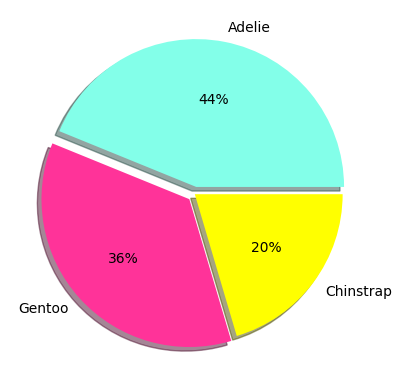

In [ ]:
myexplode = [0.05, 0.05, 0]
plt.pie(df_pen['species'].value_counts(), labels=['Adelie', 'Gentoo', 'Chinstrap'], colors=["#83ffe9","#ff3399","#ffff00"], explode = myexplode, shadow=True, autopct='%.0f%%')
plt.show()

##Histogram of Features

* A series of color-coded histograms with labelled means [12] were generated below. These charts are the only ones not in the same color scheme sorted by species as with the pie chart. The data for each feature was plotted (i.e. bill length in the top left), the title for the feature was set, the number of bins and finally a color.

* Just as the stds from the initial analysis told, the data is spread out in all four histograms. The mean is not localised. The closest to having a localised mean is in "body_mass_g" where the data is skewed left and tapers towards the right. The mean is slightly left of centre due to the spike in data on the left. There are outliers that weigh more than 6000g on the right of the histogram.

* The "flipper_length_mm" mean is the most central, but it is difficult to tell if the mean is representative as it was pulled to the left by the dip just after 200. If the dip wasn't there but merely a taper the spike at 190 would be closer to the mean. The data in that histogram is more like two separate groupings. On the left of the mean there is a bell-like curve with the spike at 190. Then there is the mean and the dip to the right which separates the second cluster of data which is a more level taper than the rapidly increasing spike on the right of the mean that peaks and tapers rapidly. There is roughly a sample of 2 that have flippers of less than 180mm these are outliers in the dataset.

* "bill_length_mm" has quite an even distribution with several peaks at 52, 40 and 45 respectively. After the last spike to the right there is a sharp drop off with the last outliers with the longest bills at 58mm. There is less of a drop off on the right where on the left there is a drop at 35mm but to the left of that bin there are no samples.

* "bill_depth_mm" has a general and rounded increase as the depth increases, reaching a peak at 18.5mm before falling rapidly after 19mm and after 20mm. Unlike in "bill_length_mm" there are no true outliers as penguins with the deepest bills still number roughly 10 whereas with "bill_length_mm" the penguins with the largest bills after 54mm there are probably 3 that have 55mm and 2 that have bills of just under 60mm.

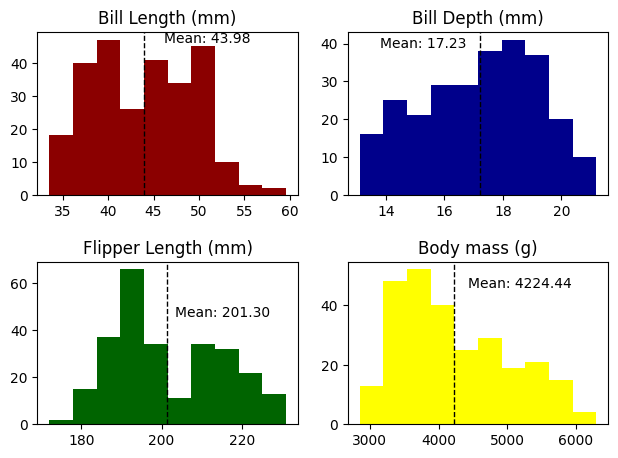

In [ ]:
fig, ax = plt.subplots(2,2)
n_bins = 10

min_ylim, max_ylim = plt.ylim()

ax[0, 0].hist(train['bill_length_mm'], n_bins, color="darkred");
ax[0, 0].set_title('Bill Length (mm)');
ax[0, 0].axvline(train['bill_length_mm'].mean(), color='k', linestyle='dashed', linewidth=1)
ax[0, 0].text(train['bill_length_mm'].mean()*1.05, max_ylim*46, 'Mean: {:.2f}'.format(train['bill_length_mm'].mean()))

ax[0, 1].hist(train['bill_depth_mm'], n_bins, color="darkblue");
ax[0, 1].set_title('Bill Depth (mm)');
ax[0, 1].axvline(train['bill_depth_mm'].mean(), color='k', linestyle='dashed', linewidth=1)
ax[0, 1].text(train['bill_depth_mm'].mean()*0.80, max_ylim*39, 'Mean: {:.2f}'.format(train['bill_depth_mm'].mean()))


ax[1, 0].hist(train['flipper_length_mm'], n_bins, color="darkgreen");
ax[1, 0].set_title('Flipper Length (mm)');
ax[1, 0].axvline(train['flipper_length_mm'].mean(), color='k', linestyle='dashed', linewidth=1)
ax[1, 0].text(train['flipper_length_mm'].mean()*1.01, max_ylim*46, 'Mean: {:.2f}'.format(train['flipper_length_mm'].mean()))


ax[1, 1].hist(train['body_mass_g'], n_bins, color="yellow");
ax[1, 1].set_title('Body mass (g)');
ax[1, 1].axvline(train['body_mass_g'].mean(), color='k', linestyle='dashed', linewidth=1)
ax[1, 1].text(train['body_mass_g'].mean()*1.05, max_ylim*46, 'Mean: {:.2f}'.format(train['body_mass_g'].mean()))
fig.tight_layout(pad=1.5)

##Box plots of features

* A series of box plots were created displaying features such as "bill_length_mm", by species such as "Gentoo". The plots have the same color scheme as the pie chart. Any white dot that you see represents an outlier of the data.

* In "bill_length_mm", "Adelie" penguins have the shortest bills by far. "Gentoo" and "Chinstrap" have similar ranges respectively. When analysing the histogram of this data, it was noted that there were two samples that were outliers for the largest "bill_length_mm". This can be seen represented by the white dots above "Gentoo" and "Chinstrap" with a "Gentoo" penguin being recorded with the largest overall bill.

* The "bill_depth_mm" shows "Gentoo" lagging behind this time. "Adelie" penguins lead for deepest bill ahead of "Chinstrap" but the range for "Adelie" goes higher and lower than "Chinstrap" this means the smallest "Chinstrap" bill is deeper than the smallest "Adelie" but the deepest "Adelie" bill is deeper than the deepest "Chinstrap"  

* The "flipper_length_mm" for "Adelie" falls as the lowest. The species with the second largest average flipper is "Chinstrap" with a larger maximum than "Adelie". This means the average "Chinstrap" will have longer flippers and the biggest "Chinstraps" will have longer flippers than the largest "Adelie" but the smallest "Adelie" flippers of are the same size. There are outliers that have a max flipper length approximately the same as or just under the max of the "Chinstrap" but the "Adelie" outliers on the lower end have smaller flippers than even the smallest "Chinstrap" flipper length. Both "Chinstrap" maximum length and "Adelie" maximum outliers however have larger flippers than the lower end of the "Gentoo" range. "Gentoo" have the longest flippers of all species.

* The "body_mass_g" for "Adelie" and "Chinstrap" penguins have a majority range that is quite similar. "Gentoo" has a majority with the highest mass. The range for "Adelie" penguins goes lower than the minimum "Chinstrap" body weight and higher than their maximum. There is one "Chinstrap" outlier that matches the maximum value of "Adelie".

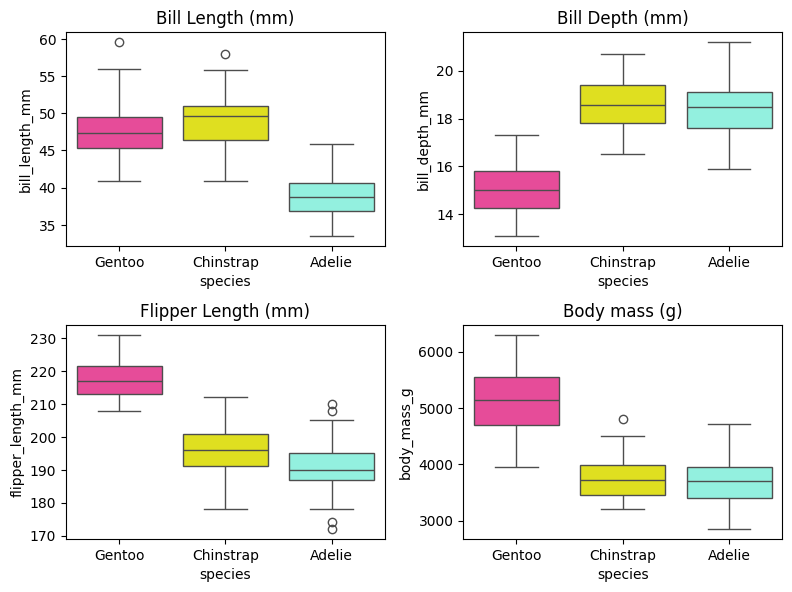

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
cn = ['Chinstrap','Adelie','Gentoo']

species_colors = {
    'Adelie': '#83ffe9',
    'Gentoo': '#ff3399',
    'Chinstrap': '#ffff00'
}


sns.boxplot(x='species', y='bill_length_mm', data=train, ax=ax[0,0], palette=species_colors, hue='species',);
ax[0, 0].set_title('Bill Length (mm)');

sns.boxplot(x='species', y='bill_depth_mm',data=train, ax=ax[0,1], palette=species_colors, hue='species');
ax[0, 1].set_title('Bill Depth (mm)');
sns.boxplot(x='species', y='flipper_length_mm',data=train, ax=ax[1,0], palette=species_colors, hue='species');
ax[1, 0].set_title('Flipper Length (mm)');
sns.boxplot(x='species', y='body_mass_g',data=train, ax=ax[1,1], palette=species_colors, hue='species');
ax[1, 1].set_title('Body mass (g)');

fig.tight_layout(pad=1.0)

##Calculate and Visualise Correlations

* A copy of train was created before editing "train_copy". In the copy, features such as species, island and sex were changed from string values to integers. This was in order to generate a heatmap to visualise correlations.

* pd.set_option() was used to block downcasting so that when pandas libraries are updated, the dataset isn't effected.

* In a personal communication with my colleague Alex Paton the implementation of blocking downcasting was discussed. [9] {"implementation of blocking downcasting"}

In [ ]:
#Enabling future behavior
pd.set_option('future.no_silent_downcasting', True)

train_copy = train.copy()

train_copy['species'] = train_copy['species'].replace({'Adelie':0,'Gentoo':1,'Chinstrap':2})
train_copy['island'] = train_copy['island'].replace({'Dream':0,'Biscoe':1,'Torgersen':2})
train_copy['sex'] = train_copy['sex'].replace({'female':0,'male':1})

* The head of "train" was printed to compare with the data before and after substituting the strings.

In [ ]:
train.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
200,Gentoo,Biscoe,44.9,13.3,213.0,5100.0,female,2008
329,Chinstrap,Dream,50.7,19.7,203.0,4050.0,male,2009
269,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,male,2009
123,Adelie,Torgersen,41.4,18.5,202.0,3875.0,male,2009
38,Adelie,Dream,37.6,19.3,181.0,3300.0,female,2007


* The head of "train_copy" was printed to show the replaced strings.

In [ ]:
train_copy.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
200,1,1,44.9,13.3,213.0,5100.0,0,2008
329,2,0,50.7,19.7,203.0,4050.0,1,2009
269,1,1,48.8,16.2,222.0,6000.0,1,2009
123,0,2,41.4,18.5,202.0,3875.0,1,2009
38,0,0,37.6,19.3,181.0,3300.0,0,2007


* The format of the data before editing the train copy meant that with strings the .corr() function didn't work. The function works by comparing features to find correlations and therefore, since strings cannot be compared with integers the corr function wouldn't work unless the data was changed from strings to integers. The data below shows correlation between features in a table format. This can be useful for data analysis, but this can be improved upon to visualise correlation easier.

In [ ]:
print(train_copy.corr())

                    species    island  bill_length_mm  bill_depth_mm  \
species            1.000000 -0.446340        0.781040      -0.179237   
island            -0.446340  1.000000       -0.236525      -0.204276   
bill_length_mm     0.781040 -0.236525        1.000000      -0.248678   
bill_depth_mm     -0.179237 -0.204276       -0.248678       1.000000   
flipper_length_mm  0.339314  0.160798        0.642902      -0.593336   
body_mass_g        0.212286  0.167584        0.582303      -0.498458   
sex                0.028701 -0.051126        0.357399       0.358628   
year              -0.030150  0.052803        0.023270      -0.056838   

                   flipper_length_mm  body_mass_g       sex      year  
species                     0.339314     0.212286  0.028701 -0.030150  
island                      0.160798     0.167584 -0.051126  0.052803  
bill_length_mm              0.642902     0.582303  0.357399  0.023270  
bill_depth_mm              -0.593336    -0.498458  0.358628 -0.

##Heatmap
* The heatmap below was created using the heatmap function in the seaborn library. The corr_mtx, annotation, the minimum and maximum values along with linewidth and line color are all passed as arguments to and(apart from the corr_mtx which passes the data) is used to style [13] the map. Here the map is set to the default color scheme. Since the average color is maroon the choice of green was used for the lines as it is maroon's contrasting color on the color wheel. This was intended to help make the data stand out.

* There is a direct correlation between a feature and itself (i.e. where "species" and "species" intersect there will be a 1) therefore, these values were removed for white space in order to analyse the rest of the data without distraction.

* The lighter the color the better correlation. For example, body mass and bill length have a correlation coefficient of 0.88. This is a strong correlation and makes sense as larger penguins will have longer bills and weigh more. The darker the color the worse the correlation. This can still be useful to know and provide insights. Bill depth and flipper length are negatively correlated having a coefficient of -0.58. In the box plots it was shown that "Gentoo" had both the shortest average bill depth and longest flippers. The other two species lead in bill depth but had shorter flippers leading to this negative coefficient.



<Axes: >

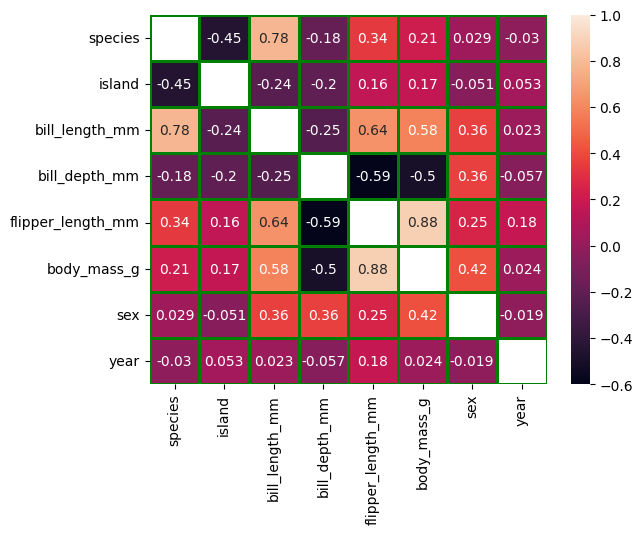

In [ ]:
corr_mtx = train_copy.corr()
mask = np.zeros_like(corr_mtx)
np.fill_diagonal(mask, True)
sns.heatmap(corr_mtx, annot=True, vmin=-0.6, vmax=1, linewidths=0.75, linecolor='green', mask=mask)

##Pairplot
* The simplest description of a pairplot is a heatmap but with datapoints instead of a correlation co-efficient in the intersections. The species were given the same color-scheme as the pie chart for ease of analysis. ipywidgets was imported to show the pairplots based on species.

* The pairplot helps to visualise the data whereas a boxplot or histogram make trends more obvious than individual points. The pairplot has each datapoint in a specific location that is more apparent than in the other visualised methods. The trend lines also still show correlation but the main point of a pairplot would be to go further into detail on a sample-by-sample basis and more in depth analysis than general trends, although the data does still reinforce the analysis of the other charts.

* Previously when printing feature names code was created to store "target_names". This time the same code was used and stored in "unique_species".  

* The pairplot contains lines to show trends [14] in the data and a way to visualise each species on its own. Where a feature is plot against itself a gaussian curve appears.

* This pairplot shows each species highlighted on its own if you select the arrow at the top of the window. This means you can select the data you find important to visualise i.e. only the "Gentoo" species.[15]

* In personal communication with my colleague Alex Paton the code to display the species indiviually with the other two greyed out was discussed. [9] {"displaying individual species"}


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

In [ ]:
# DataFrame with a 'species' column
def plot_pairplot(species):
    # Get a color palette with distinct colors for each species
    #This is the code reused from the feature names section:
    unique_species = train['species'].unique()
    palette = species_colors

    if species == "All species":
        # Plot all species with their respective colors
        sns.pairplot(train, hue='species', palette=species_colors)
    else:
        # Highlight selected species and gray out others
        train['highlight'] = train['species'] == species  # Temporary highlight column

        # Plot all data but with a regression line for the selected species
        sns.pairplot(
            train,
            hue='highlight',
            palette={True: species_colors[species], False: (0.9, 0.9, 0.9)},  # Gray out non-selected
            kind="reg",
            plot_kws={'line_kws': {'color': 'red'}}  # Regression line in red
        )

        train.drop(columns='highlight', inplace=True)  # Clean up the temporary column

    plt.show()

# Create an interactive widget with an additional "All species" option
species_options = ["All species"] + list(train['species'].unique())  # Add "All species" to the options
interact(plot_pairplot, species=widgets.Dropdown(options=species_options, description='Species:'));

interactive(children=(Dropdown(description='Species:', options=('All species', 'Gentoo', 'Chinstrap', 'Adelie'…

##Facegrid
* The facegrid method can be used to take a singular graph from the pairplot. This can be useful due to how "busy" the pairplot can be. In this case flipper length was plotted against body mass which reinforces the learnings from the boxplot that "Gentoo" penguins are larger with longer flippers (with a positive correlation coefficient also previously mentioned) than other species.

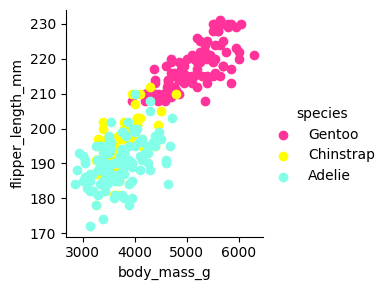

In [ ]:
sns.FacetGrid(train, hue='species', palette=species_colors, ).map(plt.scatter, 'body_mass_g', 'flipper_length_mm').add_legend();


* Four arrays were created in order to train and test the data. Features were stored in x_train and x_test and species were stored in y_train and y_test.

In [ ]:
x_train = train[['body_mass_g','flipper_length_mm','bill_length_mm','bill_depth_mm']]
y_train = train['species']
x_test = test[['body_mass_g','flipper_length_mm','bill_length_mm','bill_depth_mm']]
y_test = test['species']

* Output of training and test data on the X-Axis:
* There is a nice shuffling of data for each set which will help with training. The data output is the features as expected.

In [ ]:
print("Training Data:\n", x_train)
print("Test Data:\n", x_test)

Training Data:
      body_mass_g  flipper_length_mm  bill_length_mm  bill_depth_mm
200       5100.0              213.0            44.9           13.3
329       4050.0              203.0            50.7           19.7
269       6000.0              222.0            48.8           16.2
123       3875.0              202.0            41.4           18.5
38        3300.0              181.0            37.6           19.3
..           ...                ...             ...            ...
24        3800.0              180.0            38.8           17.2
325       3675.0              198.0            49.8           17.3
43        4400.0              196.0            44.1           19.7
187       5400.0              220.0            48.4           16.3
70        3600.0              190.0            33.5           19.0

[266 rows x 4 columns]
Test Data:
      body_mass_g  flipper_length_mm  bill_length_mm  bill_depth_mm
262       5000.0              216.0            50.5           15.2
338       

* Output of training and test data on the Y-Axis
* The data is shuffled and on output we can see the sepecies printed.

In [ ]:
print("Training Data:\n", y_train)
print("Test Data:\n", y_test)

Training Data:
 200       Gentoo
329    Chinstrap
269       Gentoo
123       Adelie
38        Adelie
         ...    
24        Adelie
325    Chinstrap
43        Adelie
187       Gentoo
70        Adelie
Name: species, Length: 266, dtype: object
Test Data:
 262       Gentoo
338    Chinstrap
93        Adelie
240       Gentoo
222       Gentoo
         ...    
196       Gentoo
122       Adelie
207       Gentoo
98        Adelie
65        Adelie
Name: species, Length: 67, dtype: object


#Create & Fit the Decision Tree Classifier

* Imports for the decision tree are shown below:

In [ ]:
from sklearn import tree
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score

* A classifier was created using the DecisionTreeClassifier() function with the argument using entropy as the criterion [16] for making decisions.
The .fit() function was passed the training arrays to fit to the decision tree.

In [ ]:
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf = clf.fit(x_train, y_train)

#Model Test & Evaluation

* The predict function was passed the features from the test array and stored predictions in y_predict which you can see below.

In [ ]:
y_predict = clf.predict(x_test)
print(y_predict)

['Gentoo' 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo' 'Gentoo' 'Chinstrap'
 'Adelie' 'Adelie' 'Gentoo' 'Chinstrap' 'Adelie' 'Adelie' 'Chinstrap'
 'Chinstrap' 'Adelie' 'Chinstrap' 'Adelie' 'Chinstrap' 'Gentoo'
 'Chinstrap' 'Gentoo' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie' 'Adelie'
 'Chinstrap' 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie' 'Adelie'
 'Adelie' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Gentoo'
 'Chinstrap' 'Gentoo' 'Chinstrap' 'Adelie' 'Gentoo' 'Chinstrap' 'Gentoo'
 'Chinstrap' 'Gentoo' 'Adelie' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie'
 'Adelie' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie' 'Gentoo' 'Gentoo'
 'Adelie' 'Gentoo' 'Adelie' 'Adelie']


* The code below checks the accuracy of the model by checking the predicted values vs the actual data. There was an error of about 6%

In [ ]:
accuracy = metrics.accuracy_score(y_test, y_predict)
print(accuracy)

0.9402985074626866


##Perform Cross-Validation

* Cross validation boils down to two questions: What is it and why use it? To answer the first question: "Cross validation is a technique used in machine learning to evaluate the performance of a model on unseen data." [17] A helpful metaphor to use is to pretend that you are a teacher giving your machine learning model answers to a test or this case you give it the "penguins" dataset. The model will then be able to sit the "test" i.e. make predictions. Since you have given it the answers however, there is no way to tell that if you gave the model a different test it would still perform as well as it did when it "knew" the answers. This is what cross validation does. It gives a different test to check the model isn't just learning the answers (i.e. overfitting) but actually performs what is was trained to do; in this case, identify penguin species fron specific traits.

##K-fold Cross Validation
* There are multiple methods of cross validation, but some are more commonly used than others. K-fold cross validation [17] is when a dataset is split into a number of "folds". For example, it is common to split data into 5 or 10 of these folds and then leave one subset to test the model and train the model with the rest.

* This model was trained with 10 folds and the cross_val_score [17] method determined the accuracy of the model. The ten scores were stored in "scores" and the mean and std of the scores were printed. The fact that the cross-validation score is quite close to the accuracy score is reassuring and tells us that the model was trained correctly. There is a std of roughly 3.7% which states the scores vary but the mean remains noteable.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score, LeaveOneOut

k_folds = KFold(n_splits = 10)

scores = cross_val_score(clf, x_train, y_train, cv = k_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("+- CV Score: ", scores.std())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [1.         0.92592593 0.96296296 0.88888889 0.96296296 0.88888889
 0.96153846 1.         0.96153846 0.92307692]
Average CV Score:  0.9475783475783477
+- CV Score:  0.037838147309816224
Number of CV Scores used in Average:  10


##Leave one out (Loo)
* Leave one out cross validation [17] trains the model on the entire dataset, leaving one datapoint to then test with. This cross validation has higher variation as the datapoint left out could be an outlier but there is low bias in Loo as all of the datapoints are in use.

* The fact that the scores for Loo and K-fold cross validation are remarkably similar may also boost confidence in the model's training but is should be noted that while the mean for Loo is assuring the std is 17%.

* Both methods of cross validation do have the same approximate average as the origional model which is reassuring. This means the range of scores is wildly varying and leads to the conclusion that loo in this case shouldn't be trusted as much as K-fold cross validation.

In [ ]:
loo = LeaveOneOut()

scores = cross_val_score(clf, x_train, y_train, cv = loo)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("+- CV Score: ", scores.std())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
Average CV Score:  0.9699248120300752
+- CV Score:  0.17079423596391802
Number of CV Scores used in Average:  266


##Decision Tree Output

* In order for each node to be pure i.e.contain only one class [2]. A class in this case would be one of the species of penguin. There are a total of 6 layers in the decision tree. The tree uses the four key features in the histograms and boxplots: the penguins' mass, flipper length, bill length and bill depth to sort data into pure nodes.
* For example, node #6 contains one "Adelie" penguin by first comparing the entire dataset by thresholds in flipper length, bill length, bill length again (at a separate threshold), bill depth and a final bill length comparison.

* A Diagram of the decision tree is output below:

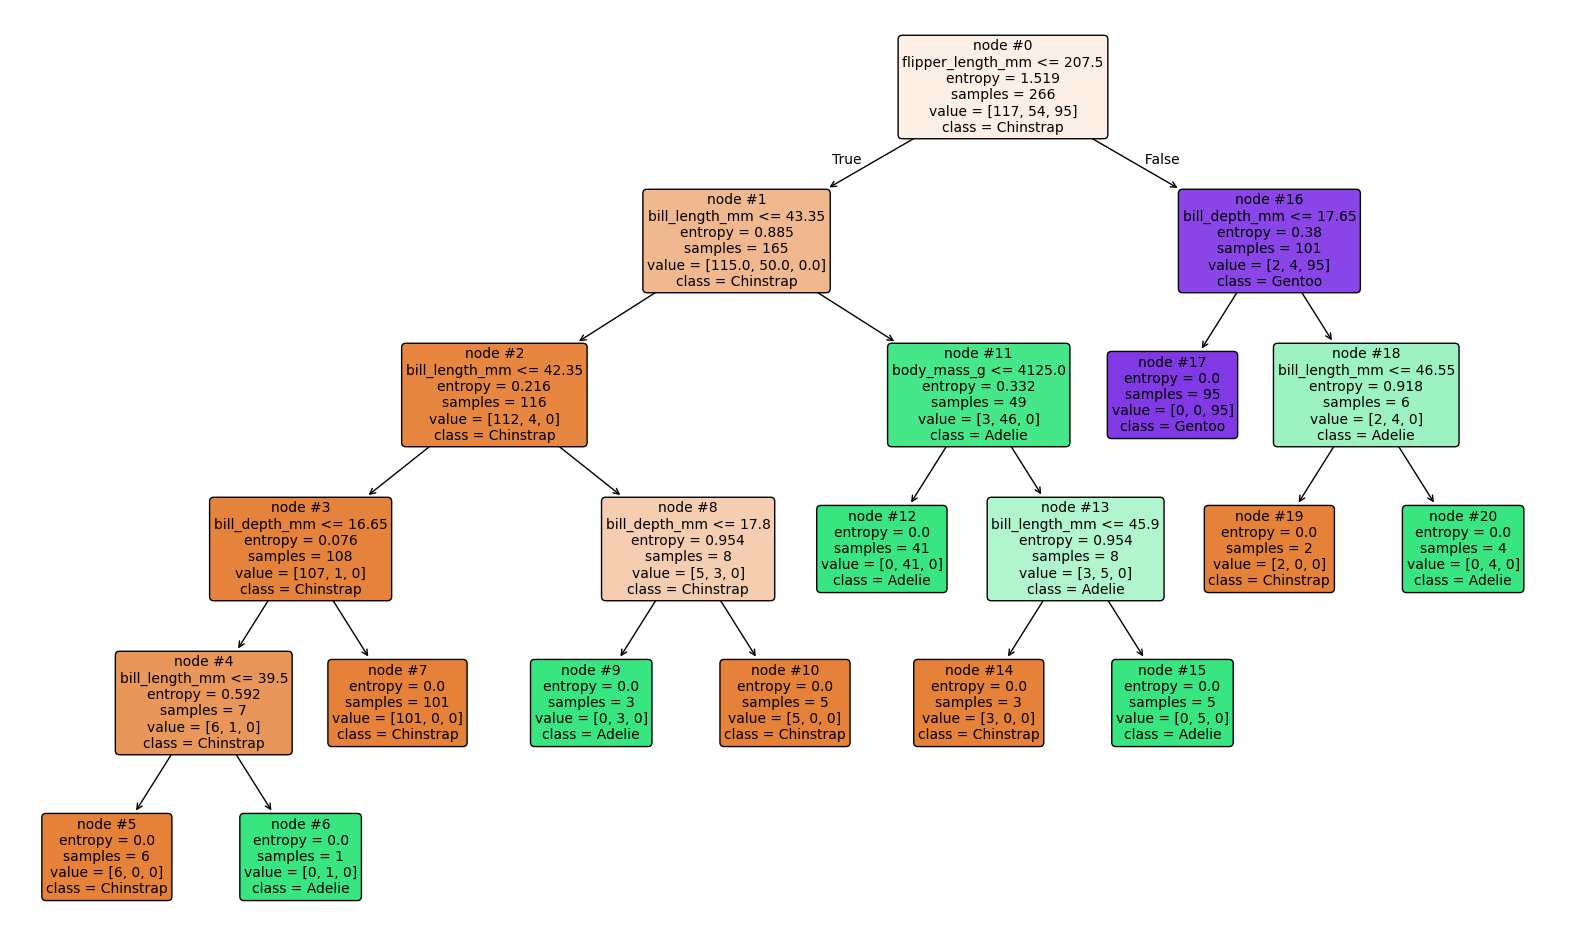

In [ ]:
from matplotlib.colors import to_rgb
fig, ax = plt.subplots(1, 1, figsize=(20, 12))
fn = ['body_mass_g','flipper_length_mm','bill_length_mm','bill_depth_mm']
cn = ['Chinstrap','Adelie','Gentoo']
artists = tree.plot_tree(clf, feature_names=fn, class_names=cn, filled=True, node_ids=True, fontsize=10, rounded=True);

##Bootstrap Aggregation

* Due to Decision Trees' nature of being prone to overfitting [18], bagging was used to improve accuracy and performance. Bootstrap Aggregation is an example of ensemble modelling which uses "multiple machine learning models to improve overall predictive performance." [19].

* "Models are trained on a random subset of the data sampled with replacement, meaning that the individual data points can be chosen more than once." [19] The predictions of the individual models are then combined and averaged in order to make a prediction. This leads to a reduction in "variance and overfitting." [19]

* The base classifier was evaluated earlier, ending up with an accuracy of roughly 94%. Now the bagging classifier was created and also be shown to outperform that figure.

* The "BaggingClassifier" was imported before an estimator range was created. This range is the number of models the classifier will group the predictions of.

* A for loop was used to store the models and scores for the classifier. This was to see which number of estimators performed the greatest.

* A graph was used to visualise the scores for each estimator below. In the range 6-10 for the number of estimators the model was 97% accurate which was a huge improvement given the model's score was already ~94%.

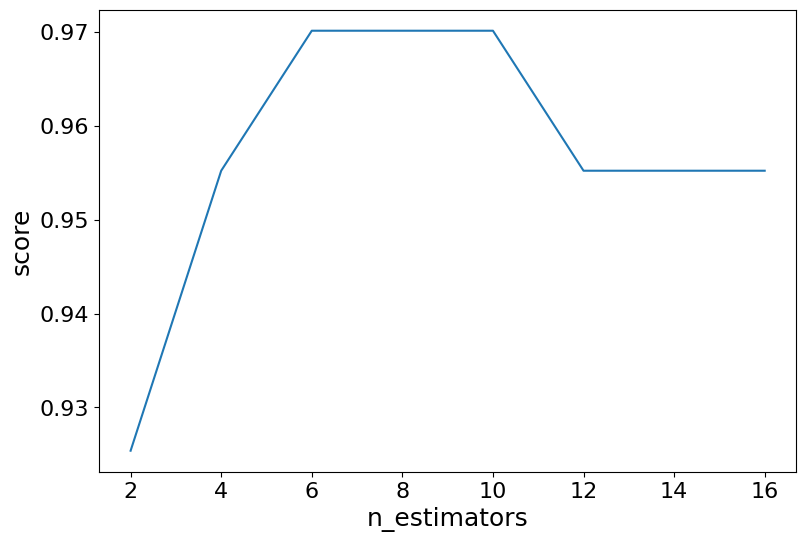

In [ ]:
from sklearn.ensemble import BaggingClassifier
estimator_range = [2,4,6,8,10,12,14,16]

models = []
scores = []

for n_estimators in estimator_range:

    # Create bagging classifier
    clf = BaggingClassifier(n_estimators = n_estimators, random_state = 22)

    # Fit the model
    clf.fit(x_train, y_train)

    # Append the model and score to their respective list
    models.append(clf)
    scores.append(accuracy_score(y_true = y_test, y_pred = clf.predict(x_test)))

# Generate the plot of scores against number of estimators
plt.figure(figsize=(9,6))
plt.plot(estimator_range, scores)

# Adjust labels and font (to make visable)
plt.xlabel("n_estimators", fontsize = 18)
plt.ylabel("score", fontsize = 18)
plt.tick_params(labelsize = 16)

# Visualize plot
plt.show()

##Plot Confusion Matrix

* A plot confusion matrix shows the predicted labels vs the actual data so one
can visualise the accuracy of the model. The prediction model had an error of approximately 5.9% in the end predicting all but 4 points out of a total 67 incorrectly This result matches the printed accuracy earlier. "Gentoo" penguins had no false positives it should be noted.

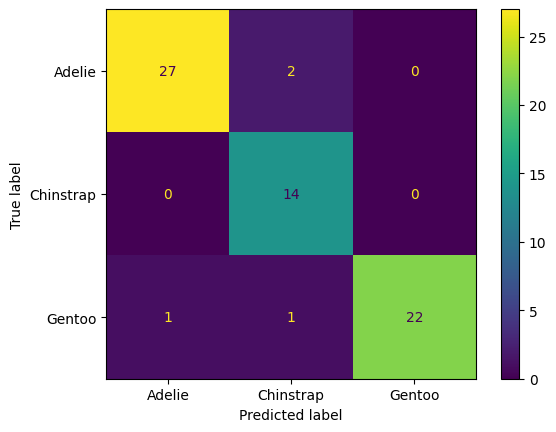

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_predict);

# References

[1] A. Horst, "palmerpenguins," 2022. [Online]. Available: https://github.com/allisonhorst/palmerpenguins. [Accessed 15 11 2023].

[2] Wikipedia, "Decision Tree," [Online]. Available: https://en.wikipedia.org/wiki/Decision_tree. [Accessed 15 11 2023].

[3] V. Maini. (2017, Aug 19). *Machine Learning for Humans* [online]. Available: https://medium.com/machine-learning-for-humans/why-machine-learning-matters-6164faf1df12.

[4] M. Lynch, “Machine Learning with Python”, Lecture, ATU, Galway, 2023.

[5] UCI Machine Learning Reposistory, "Palmer Penguins," [Online]. Available: https://archive.ics.uci.edu/dataset/690/palmer+penguins-3

[6] Geeks for Geeks, "Ways to import CSV files in Google Colab,"[Online]. Available: https://www.geeksforgeeks.org/ways-to-import-csv-files-in-google-colab/

[7] W3Schools, "Pandas DataFrame describe() Method,"[Online]. Available: https://www.w3schools.com/python/pandas/ref_df_describe.asp

[8] stackoverflow "df.isnull().sum() is still showing values as null,even though I dropped na values using dropna function.Why?" [Online]. Available: https://stackoverflow.com/questions/62980409/df-isnull-sum-is-still-showing-values-as-null-even-though-i-dropped-na-value

[9] A.Paton, Personal Communication, Nov. 2024

[10] scikitlearn, "train_test_split,"[Online]. Available: https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.train_test_split.html

[11] W3Schools, "Matplotlib Pie Charts,"[Online]. Available: https://www.w3schools.com/python/matplotlib_pie_charts.asp

[12] stackoverflow, "Drawing average line in histogram,"[Online]. Available:  https://stackoverflow.com/questions/16180946/drawing-average-line-in-histogram

[13] C.Shaw, "How to customize Seaborn Correlation Heatmaps,"[Online]. Available: https://medium.com/@chrisshaw982/seaborn-correlation-heatmaps-customized-10246f4f7f4b

[14] builtin, "Seaborn Pairplot: A Guide,"[Online]. Available:https://builtin.com/articles/seaborn-pairplot

[15] Jupyter, "Jupyter Widgets", [Online]. Available: https://ipywidgets.readthedocs.io/en/latest/.

[16] D.Singh, "Criterion used in Constructing Decision Tree,"[Online]. Available:https://medium.com/geekculture/criterion-used-in-constructing-decision-tree-c89b7339600f

[17] W3Schools, "Machine Learning - Cross Validation,"[Online]. Available: https://w3schools.com/python/python_ml_cross_validation.asp

[18] W3Schools, "Machine Learning- Bootstrap Aggregation (Bagging)"[Online] Available: https://www.w3schools.com/python/python_ml_bagging.asp

[19] A.All Awan "What is Bagging in Machine Learning? A Guide With Examples" [Online] Available: https://www.datacamp.com/tutorial/what-bagging-in-machine-learning-a-guide-with-examples?dc_referrer=https%3A%2F%2Fwww.google.com%2F